In [15]:
import gymnasium as gym

In [16]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [18]:
class ValueNetwork(nn.Module):

    def __init__(self, n_observations, n_actions, n_hidden):
        super(ValueNetwork, self).__init__()
        self.layer1 = nn.Linear(n_observations + n_actions, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_hidden)
        self.layer3 = nn.Linear(n_hidden, 1)

    # Called with either one element to determine next action, or a batch
    # during optimization.
    def forward(self, states, actions):
        x = torch.cat([states, actions], dim=1)
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

In [19]:
class PolicyNetwork(nn.Module):
    def __init__(self, n_states, n_hidden, n_actions, max_action):
        super(PolicyNetwork, self).__init__()
        self.affine1 = nn.Linear(n_states, n_hidden)
        self.affine2 = nn.Linear(n_hidden, n_hidden)
        self.action_head = nn.Linear(n_hidden, n_actions)
        self.max_action = max_action

    def forward(self, x):
        # x is state index; convert to one-hot for the network
        x = F.relu(self.affine1(x))
        x = F.relu(self.affine2(x))
        return torch.tanh(self.action_head(x)) * self.max_action

In [76]:
env=gym.make('Pendulum-v1')

n_states = env.observation_space.shape[0]
n_actions = env.action_space.shape[0]

action_range = env.action_space.high - env.action_space.low

possible_actions = np.linspace(0, n_actions-1, n_actions)
ALPHA = 1e-4
GAMMA = 0.9
BATCH_SIZE = 32
EPSILON = 0.01
N_EPISODES = 500
TAU = 0.05
MEM_SIZE = 2000
POLICY_UPDATE = 2
NOISE_MAX = 0.5

n_hidden = 64

[4.]


In [68]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [80]:
class TD3():
    def __init__(self):
        # Define the critic A
        self.critic_a = ValueNetwork(n_states, n_actions, n_hidden).to(device)
        self.critic_target_a = ValueNetwork(n_states, n_actions, n_hidden).to(device)
        self.critic_target_a.load_state_dict(self.critic_a.state_dict())

        # Define the critic B
        self.critic_b = ValueNetwork(n_states, n_actions, n_hidden).to(device)
        self.critic_target_b = ValueNetwork(n_states, n_actions, n_hidden).to(device)
        self.critic_target_b.load_state_dict(self.critic_b.state_dict())

        # Define one optimiser for both critics
        self.critic_optimizer = optim.AdamW(list(self.critic_a.parameters()) + list(self.critic_b.parameters()), lr=ALPHA, amsgrad=True)
        
        self.memory = ReplayMemory(MEM_SIZE)

        # Define the actor
        max_action = float(env.action_space.high[0])
        self.actor = PolicyNetwork(n_states, n_hidden, n_actions,max_action)
        self.actor_target = PolicyNetwork(n_states, n_hidden, n_actions,max_action)
        self.actor_target.load_state_dict(self.actor.state_dict()) 
        self.actor_optimizer = optim.AdamW(self.actor.parameters(), lr=ALPHA, amsgrad=True)
        
        self.gamma = GAMMA

    def soft_update(self, count):
        if count % POLICY_UPDATE == 0:
            # Soft update of target actor
            for target_param, param in zip(self.actor_target.parameters(), self.actor.parameters()):
                target_param.data.copy_(target_param.data * (1.0 - TAU) + param.data * TAU)
    
        # Soft update of target critic
        for target_param, param in zip(self.critic_target_a.parameters(), self.critic_a.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - TAU) + param.data * TAU)
        for target_param, param in zip(self.critic_target_b.parameters(), self.critic_b.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - TAU) + param.data * TAU)
        

    def learn_actor(self, state_batch):
        self.actor_optimizer.zero_grad()
        
        actor_loss = -self.critic_a(state_batch, self.actor(state_batch)).mean()
        
        actor_loss.backward()
        self.actor_optimizer.step()
    
    def compute_target(self, actor, critic_target, reward_batch, non_final_mask, non_final_next_states):
        # Target Q calculation: r + gamma * Q_target(s', actor_target(s'))
        next_q_values = torch.zeros(BATCH_SIZE, device=device)
        with torch.no_grad():
            if non_final_mask.any():
                target_actions = actor(non_final_next_states)
                clipped_noise = torch.clip(torch.randn_like(target_actions) * action_range[0], -NOISE_MAX, NOISE_MAX)
                noisy_target_action = target_actions + torch.tensor((clipped_noise), dtype=torch.float32, device=device)
                noisy_target_action = torch.clip(noisy_target_action, -self.actor.max_action, self.actor.max_action)
                next_q_values[non_final_mask] = critic_target(non_final_next_states, noisy_target_action).squeeze()
                    
        return (next_q_values * self.gamma) + reward_batch

        
    def learn_critic(self, state_batch, action_batch, reward_batch, non_final_mask, non_final_next_states):                  
        # Q(s, a) from online critic
        q_values_a = self.critic_a(state_batch, action_batch)
        q_values_b = self.critic_b(state_batch, action_batch)
        
        target_a = self.compute_target(self.actor, self.critic_target_a, reward_batch, non_final_mask, non_final_next_states)
        target_b = self.compute_target(self.actor, self.critic_target_b, reward_batch, non_final_mask, non_final_next_states)
        target_value = torch.min(target_a, target_b)
        
        # Compute loss (ensuring both are [Batch, 1])
        criterion = nn.SmoothL1Loss()
        loss = criterion(q_values_a, target_value.unsqueeze(1)) + criterion(q_values_b, target_value.unsqueeze(1))
        
        self.critic_optimizer.zero_grad()
        loss.backward()
        self.critic_optimizer.step()

In [81]:
def twin_delayed_ddpg(num_episodes=200):
    td3 = TD3()
    rewards_list = []
    global_steps = 0

    for e in range(num_episodes):
        obs, info = env.reset()
        # Convert to [1, 3] tensor immediately
        state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        tot_reward = 0
        done = False
        
        while not done:
            # 1. Select Action
            with torch.no_grad():
                action = td3.actor(state)
            
            # 2. Add Exploration Noise (Standard for DDPG)
            noisy_action = action.cpu().numpy()[0] + (np.random.normal(loc=0, scale=0.1, size=n_actions))
            noisy_action = np.clip(noisy_action, -td3.actor.max_action, td3.actor.max_action)
            
            # 3. Step Environment
            state_next_obs, reward, terminated, truncated, _ = env.step(noisy_action)
            done = terminated or truncated
            tot_reward += reward

            # 4. Prepare tensors for Memory
            # Keep everything 2D for consistency
            action_tensor = torch.from_numpy(noisy_action).float().to(device).unsqueeze(0) # Convert directly from numpy to tensor, then add the batch dimension
            reward_tensor = torch.tensor([reward], dtype=torch.float32, device=device)
            state_next = torch.tensor(state_next_obs, dtype=torch.float32, device=device).unsqueeze(0) if not done else None

            td3.memory.push(state, action_tensor, state_next, reward_tensor)
            state = state_next 

            # 5. Optimize
            if len(td3.memory) >= BATCH_SIZE:
                transitions = td3.memory.sample(BATCH_SIZE)
                batch = Transition(*zip(*transitions))
                
                # Masks and batching
                non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool)
                non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
                
                state_batch = torch.cat(batch.state)   # [32, 3]
                action_batch = torch.cat(batch.action) # [32, 1]
                reward_batch = torch.cat(batch.reward) # [32]
                
                td3.learn_critic(state_batch, action_batch, reward_batch, non_final_mask, non_final_next_states)

                if global_steps % POLICY_UPDATE == 0:
                    td3.learn_actor(state_batch)
                    
                td3.soft_update(global_steps)
            
            global_steps += 1

        rewards_list.append(tot_reward)
        if e % 10 == 0:
            print(f"Episode {e} | Reward: {tot_reward:.2f}")
            
    return rewards_list

In [82]:
rewards = twin_delayed_ddpg(num_episodes=N_EPISODES)

/tmp/ipykernel_24/3534406169.py:55: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  noisy_target_action = target_actions + torch.tensor((clipped_noise), dtype=torch.float32, device=device)


Episode 0 | Reward: -1682.21
Episode 10 | Reward: -1075.36
Episode 20 | Reward: -1728.64
Episode 30 | Reward: -1264.20
Episode 40 | Reward: -1188.92
Episode 50 | Reward: -1349.21
Episode 60 | Reward: -1422.57
Episode 70 | Reward: -1596.03
Episode 80 | Reward: -1534.44
Episode 90 | Reward: -1458.90
Episode 100 | Reward: -1414.22
Episode 110 | Reward: -1434.34
Episode 120 | Reward: -1324.20
Episode 130 | Reward: -1243.18
Episode 140 | Reward: -1276.37
Episode 150 | Reward: -1218.62
Episode 160 | Reward: -1236.97
Episode 170 | Reward: -840.07
Episode 180 | Reward: -1254.00
Episode 190 | Reward: -1340.24
Episode 200 | Reward: -1107.66
Episode 210 | Reward: -878.05
Episode 220 | Reward: -905.99
Episode 230 | Reward: -1133.21
Episode 240 | Reward: -1243.93
Episode 250 | Reward: -1103.99
Episode 260 | Reward: -1397.08
Episode 270 | Reward: -1269.33
Episode 280 | Reward: -1238.39
Episode 290 | Reward: -890.05
Episode 300 | Reward: -1279.47
Episode 310 | Reward: -1391.07
Episode 320 | Reward: -

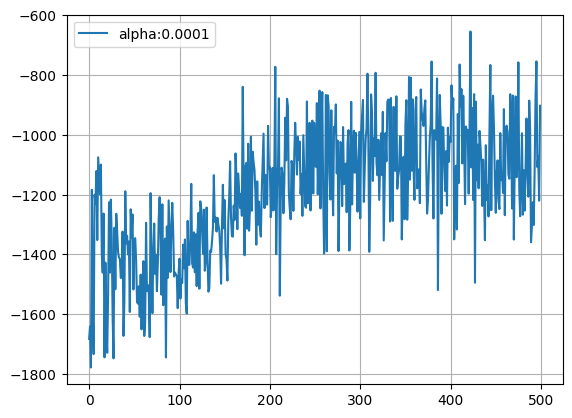

In [83]:
plt.grid()
plt.plot(rewards, label="alpha:"+str(round(ALPHA, 4)))
plt.legend()